# **Company & Sector Admin Panel**

**Author:** Milos Saric [https://saricmilos.com/]  
**Date:** January 15, 2026  
**Dataset:** Sample CSVs provided (companies and sectors), augmented with synthetic data  

---

This project implements an **Admin Panel** for managing company and sector data. The panel allows internal users to **browse, search, and edit** company information, link companies to sectors, and visualize relationships. It demonstrates a **full-stack solution** including a Python backend, React frontend, and a database, all containerized for deployment.  

**Objective:**  
To build a maintainable and functional admin interface for internal data management, while demonstrating backend architecture, API design, and trade-off reasoning.

The project includes:

---

## 1. Problem Definition
- Goal: Enable non-technical users to view, search, and link companies and sectors through an intuitive admin panel.  
- Requirements:
  - CRUD operations for companies and sectors
  - CSV import for batch updates
  - Search and filtering
  - Link companies to one or multiple sectors
  - Parent-child hierarchy for sectors

---

## 2. Architecture Overview
- **Backend:** FastAPI with SQLAlchemy models  
- **Database:** SQLite (Postgres optional)  
- **Frontend:** React with simple tables and forms  
- **Deployment:** Dockerized services with `docker-compose`  

The system is designed for **clarity, maintainability, and extendability**, allowing easy integration of AI-assisted features in the future.

---

## 3. Data Model
**Company**
- `id` (primary key)  
- `name`  
- `url`  
- `hq_country`  

**Sector**
- `id` (primary key)  
- `name`  
- `radius`  
- `parent_id` (nullable, for hierarchy)  

**CompanySector** (many-to-many)
- Links companies to one or more sectors

---

## 4. Backend Implementation
- **CRUD endpoints:**  
  - `POST /upload/companies` – CSV upload  
  - `POST /upload/sectors` – CSV upload  
  - `GET /companies?search=` – Filter companies  
  - `GET /sectors` – List sectors  
  - `POST /assign-sector` – Link company to sector  
- **Trade-offs:**  
  - Simplified hierarchy traversal for sectors  
  - Basic CSV validation only  
  - Focused on correctness over full scalability  

---

## 5. Frontend Implementation
- Upload CSVs and view tables  
- Search/filter companies  
- Assign sectors using dropdowns  
- Minimal styling for fast delivery  
- Trade-off: UX simplified to focus on **functionality and demonstration**

---

## 6. AI / Automation Potential
- AI could assist with:
  - Predicting sector assignments for new companies  
  - Suggesting parent-child relationships  
  - Validating data quality automatically  
- Limitations:
  - AI suggestions would need human review  
  - Current implementation uses **manual linking**  

---

## 7. Deployment
- Dockerized backend, frontend, and database  
- `docker-compose up` starts all services  
- Ready for cloud deployment (optional)  

---

## 8. Future Work
- Enhance sector hierarchy management  
- Add user authentication and roles  
- Integrate AI for automated sector assignment  
- Improve UI/UX with better table filtering and visualization
- Migrate to Postgres for larger datasets

---

**Conclusion:**  
This project demonstrates a **full-stack admin system** with backend APIs, database models, and a React frontend, showcasing both **engineering judgment** and **trade-off decisions** in delivering a maintainable system for internal users.


# **Company & Sector Admin Panel**

Managing company and sector data effectively is critical for internal teams to make informed business decisions. Companies have attributes such as **name**, **URL**, **headquarter country**, and assigned **sectors**, while sectors can have **parent-child relationships** and additional attributes like **radius**. Ensuring this data is **accurate, accessible, and editable** allows teams to analyze markets, track industry trends, and streamline reporting.

In modern business environments, an **Admin Panel** enables non-technical users to browse, search, link, and update company and sector data without relying on engineering teams. This reduces bottlenecks, ensures data quality, and accelerates decision-making across departments.

Key benefits of a well-designed Admin Panel include:

- **Streamlined Data Management:** Quickly upload, search, and edit company and sector records.  
- **Accurate Sector Assignments:** Enable correct linking between companies and sectors, including hierarchical relationships.  
- **Improved Productivity:** Reduce dependency on engineering teams for internal data updates.  
- **Scalable Architecture:** Prepare for future AI-assisted features, automated data validation, or analytics dashboards.  
- **Maintainable System:** Clean, modular backend and frontend structure that can grow with the organization.

---

## **1. Problem Definition**

The first step is to clearly define the Admin Panel requirements to ensure the system meets the needs of internal users and aligns with business objectives.

### **Objective**
Develop a **full-stack admin panel** that allows internal users to:

- Browse, search, and view companies and sectors  
- Upload and edit company and sector data via CSV or forms  
- Assign companies to sectors, including managing sector hierarchy  
- Maintain data integrity while supporting scalability and future AI integration  

### **Scope**
The system focuses on managing structured data about companies and sectors:

- **Company Data:** Name, URL, headquarters country  
- **Sector Data:** Name, radius, optional parent sector  
- **Relationships:** Many-to-many mapping between companies and sectors  

Optional: Augment sample datasets with synthetic company records for demonstration purposes.

### **Stakeholders**
- **Corporate Strategy Teams / Analysts:** Analyze markets and track sector trends.  
- **Data & Operations Teams:** Keep internal databases accurate and up-to-date.  
- **Non-Technical Staff:** Easily edit and browse company and sector data without technical support.  
- **Data Scientists / ML Engineers:** Potentially leverage structured data for analytics or AI-assisted insights.

### **Success Criteria**
A successful Admin Panel should:

- Enable users to **upload, view, search, and link** company and sector records efficiently  
- Handle sector hierarchy and company-sector assignments correctly  
- Be **deployable and containerized** (Docker / Docker Compose)  
- Demonstrate clear architecture, clean code, and maintainability  

> A well-defined Admin Panel allows organizations to manage company and sector data efficiently, reduces bottlenecks, and lays the foundation for scalable analytics and AI-assisted operations.

## **2. Data Collection**

The **Data Collection** phase focuses on gathering and preparing the datasets required to build and evaluate our company admin panel. This step also involves importing essential libraries, setting up the working environment, and organizing reusable functions to ensure a smooth analysis workflow.

## **Dataset Description**



---

We can begin by:
1. Loading each dataset (`challenge_companies`, `challenge_company_sectors`,`challenge_sectors`) individually.  
2. Performing exploratory data analysis (EDA) to understand distributions and missing values.

### Setting working paths

In [20]:
import sys
from pathlib import Path

In [21]:
# Go up one level from /notebooks to the main folder
project_root = Path.cwd().parent

In [22]:
sys.path.append(str(project_root))

# Required Libraries Import

### Core Libraries

In [23]:
import pandas as pd

### Modules

In [58]:
%load_ext autoreload
%autoreload 2

from src.dataloader import load_all_csvs_from_folder
from src.missing_values import (
    missing_values_heatmap,
    missing_values_barchart,
    get_missing_value_summary
    )
from src.unique_values import (
    get_column_types,
    plot_number_of_unique_values,
    unique_values
    )

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load Datasets

In [25]:
# Build the path to the data file
data_path = project_root / "data"

In [26]:
datasets = load_all_csvs_from_folder(data_path,low_memory = False)

In [27]:
print(f"{datasets.keys()}")

dict_keys(['challenge_companies', 'challenge_company_sectors', 'challenge_sectors'])


In [28]:
companies_df, company_sectors_df, sectors_df = (datasets.get(key) for key in ["challenge_companies","challenge_company_sectors", "challenge_sectors"])

In [29]:
for df in [companies_df, company_sectors_df, sectors_df]:
    df.columns = (
        df.columns
        .str.strip()            # Remove leading/trailing whitespace
        .str.lower()            # Convert all column names to lowercase
        .str.replace(' ', '_', regex=False)  # Replace hyphens with underscores
    )

##  **3. Exploratory Data Analysis (EDA)**

Exploratory Data Analysis is all about **understanding the dataset**, uncovering patterns, spotting anomalies, and generating insights that will guide feature engineering and modeling.

In [30]:
shapes = pd.DataFrame({
    "Dataset": ["companies_df", "company_sectors_df","sectors_df"],
    "Shape": [companies_df.shape, company_sectors_df.shape,sectors_df.shape]
})
print(shapes.to_string(index=False))

           Dataset     Shape
      companies_df (1000, 5)
company_sectors_df (1324, 2)
        sectors_df  (182, 6)


# **3.1. Companies Dataset**

In [31]:
companies_df.head()

,cib_id,company_name,hq_country_id,operation,operation_date
0,aap-joints.com,aap Joints,DE,NEW_BATCH_MANUAL,2025-12-04
1,abacoadjusters.com,Abaco International Loss Adjusters,ES,NEW_BATCH,2024-12-15
2,abgagservices.com,ABG AG,US,NEW_BATCH_MANUAL,2025-12-04
3,abu-gmbh.ch,ABUplus,CH,NEW_BATCH_JENKINS,2025-11-27
4,abundantlivinginsurance.com,Abundant Living,US,NEW_BATCH,2024-12-22


In [32]:
companies_df.columns

Index(['cib_id', 'company_name', 'hq_country_id', 'operation',
       'operation_date'],
      dtype='object')

In [33]:
companies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   cib_id          1000 non-null   object
 1   company_name    1000 non-null   object
 2   hq_country_id   988 non-null    object
 3   operation       1000 non-null   object
 4   operation_date  1000 non-null   object
dtypes: object(5)
memory usage: 39.2+ KB


In [34]:
companies_df.describe()

,cib_id,company_name,hq_country_id,operation,operation_date
count,1000,1000,988,1000,1000
unique,1000,1000,49,5,108
top,aap-joints.com,aap Joints,CH,NEW_BATCH_JENKINS,2025-11-27
freq,1,1,390,478,319


### **3.1.2. Missing Values Information**

In [35]:
companies_df.isna().sum()

cib_id             0
company_name       0
hq_country_id     12
operation          0
operation_date     0
dtype: int64

In [36]:
get_missing_value_summary(companies_df)

,Column,Dtype,TotalValues,MissingValues,NonMissingValues,MissingPercent
0,cib_id,object,1000,0,1000,0.0
1,company_name,object,1000,0,1000,0.0
2,hq_country_id,object,1000,12,988,1.2
3,operation,object,1000,0,1000,0.0
4,operation_date,object,1000,0,1000,0.0


In [37]:
companies_df[companies_df.isnull().any(axis=1)]

,cib_id,company_name,hq_country_id,operation,operation_date
199,crisam.pe,Crisam Import,NaN,NEW_BATCH_MANUAL,2025-10-10
202,dabpharmservice.com,DAB Pharmservice,NaN,NEW_BATCH_MANUAL,2025-10-10
241,drivecure.in,Drivecure Healthcare,NaN,NEW_BATCH_MANUAL,2025-10-10
252,earthoptics.com,Earthoptics,NaN,NEW_BATCH_MANUAL,2025-10-10
401,hpeirl.com,HPE Ireland,NaN,NEW_BATCH_MANUAL,2025-10-10
422,innosignbio.com,InnoSIGN,NaN,NEW_BATCH_MANUAL,2025-10-10
592,pathovet.cl,Laboratorio Pathovet,NaN,NEW_BATCH_MANUAL,2025-10-10
736,softwarepoint.com,Whitelake Software Point,NaN,NEW_BATCH_MANUAL,2025-12-08
863,terpenia.eu,Terpenia Phytotherapeutics,NaN,NEW_BATCH_MANUAL,2025-10-10
869,theclinivex.com,Clinivex,NaN,NEW_BATCH_MANUAL,2025-10-10


In [38]:
companies_df['hq_country_id'] = companies_df['hq_country_id'].fillna(0)

In [39]:
get_missing_value_summary(companies_df)

,Column,Dtype,TotalValues,MissingValues,NonMissingValues,MissingPercent
0,cib_id,object,1000,0,1000,0.0
1,company_name,object,1000,0,1000,0.0
2,hq_country_id,object,1000,0,1000,0.0
3,operation,object,1000,0,1000,0.0
4,operation_date,object,1000,0,1000,0.0


### **3.1.3. Unique Values Information**

In [65]:
cat_cols_companies, int_cols_companies, float_cols_companies = get_column_types(companies_df)

Categorical variables:
['cib_id', 'company_name', 'hq_country_id', 'operation', 'operation_date']

Integer variables:
[]

Real (float) variables:
[]


In [61]:
unique_values(companies_df)

,Column,UniqueValues,TotalValues,UniquePercent
0,cib_id,1000,1000,100.0
1,company_name,1000,1000,100.0
2,operation_date,108,1000,10.8
3,hq_country_id,50,1000,5.0
4,operation,5,1000,0.5


In [63]:
companies_df['operation'].value_counts()

operation
NEW_BATCH_JENKINS    478
NEW_BATCH            239
NEW_BATCH_MANUAL     226
NEW_BATCH_DATAQA      47
MIGRATION             10
Name: count, dtype: int64

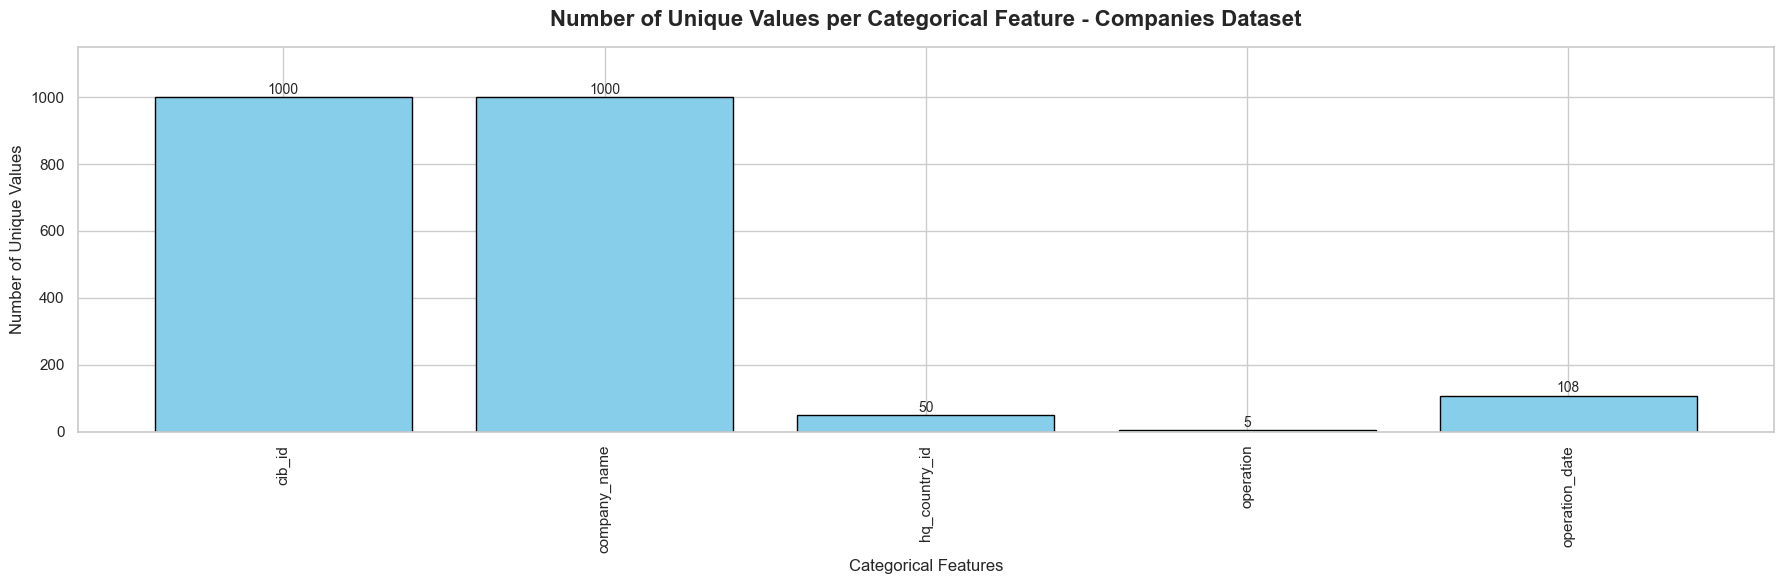

In [66]:
plot_number_of_unique_values(companies_df,cat_cols_companies,"Companies Dataset")

# **3.2. Companies Sector Dataset**

In [40]:
company_sectors_df.head()

,cib_id,sector_id
0,aap-joints.com,25
1,abacoadjusters.com,22
2,abgagservices.com,214
3,abu-gmbh.ch,167
4,abundantlivinginsurance.com,22


In [41]:
company_sectors_df.columns

Index(['cib_id', 'sector_id'], dtype='object')

In [42]:
company_sectors_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1324 entries, 0 to 1323
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   cib_id     1324 non-null   object
 1   sector_id  1324 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 20.8+ KB


NO MEANING IDS!

In [43]:
company_sectors_df.describe()

,sector_id
count,1324.000000
mean,112.470544
std,65.336178
min,5.000000
25%,32.000000
50%,153.000000
75%,167.000000
max,218.000000


### **3.2.2. Missing Values Information**

In [44]:
company_sectors_df.isna().sum()

cib_id       0
sector_id    0
dtype: int64

In [45]:
get_missing_value_summary(company_sectors_df)

,Column,Dtype,TotalValues,MissingValues,NonMissingValues,MissingPercent
0,cib_id,object,1324,0,1324,0.0
1,sector_id,int64,1324,0,1324,0.0


NO MISSING VALUES!

### **3.2.3. Unique Values Information**

In [67]:
cat_cols_company_sectors, int_cols_company_sectors, float_cols_company_sectors = get_column_types(company_sectors_df)

Categorical variables:
['cib_id']

Integer variables:
['sector_id']

Real (float) variables:
[]


In [68]:
unique_values(company_sectors_df)

,Column,UniqueValues,TotalValues,UniquePercent
0,cib_id,1000,1324,75.53
1,sector_id,60,1324,4.53


one company belong to multiple sectors

In [69]:
company_sectors_df[company_sectors_df.duplicated(subset=['cib_id'], keep=False)]

,cib_id,sector_id
17,alarm-tec.de,32
18,alarm-tec.de,218
19,alatiyahinv.com,97
20,alatiyahinv.com,154
25,alioth.group,97
...,...,...
1310,zap-wahl.de,125
1316,ziraketan.com,25
1317,ziraketan.com,214
1318,zjky-bio.com,25


# **3.3. Sector Dataset**

In [46]:
sectors_df.head()

,sector_id,sector_name,sector_radius_km,parent_sector_id,first_log_id,last_log_id
0,1,Advertising Agencies,25,NaN,NaN,NaN
1,50,Aerospace and Defense,25,NaN,NaN,NaN
2,2,Agriculture,25,NaN,NaN,NaN
3,97,Alternative Asset Management,25,NaN,NaN,NaN
4,3,Alternative Energy,25,NaN,NaN,NaN


In [47]:
sectors_df.columns

Index(['sector_id', 'sector_name', 'sector_radius_km', 'parent_sector_id',
       'first_log_id', 'last_log_id'],
      dtype='object')

In [48]:
sectors_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sector_id         182 non-null    int64  
 1   sector_name       182 non-null    object 
 2   sector_radius_km  182 non-null    int64  
 3   parent_sector_id  91 non-null     float64
 4   first_log_id      0 non-null      float64
 5   last_log_id       0 non-null      float64
dtypes: float64(3), int64(2), object(1)
memory usage: 8.7+ KB


In [49]:
sectors_df.describe()

,sector_id,sector_radius_km,parent_sector_id,first_log_id,last_log_id
count,182.000000,182.000000,91.000000,0.0,0.0
mean,93.758242,32.950549,46.978022,NaN,NaN
std,56.055683,53.909406,43.040544,NaN,NaN
min,1.000000,3.000000,4.000000,NaN,NaN
25%,46.250000,13.750000,18.000000,NaN,NaN
50%,92.500000,25.000000,27.000000,NaN,NaN
75%,138.750000,25.000000,97.000000,NaN,NaN
max,218.000000,250.000000,165.000000,NaN,NaN


### **3.3.2. Missing Values Information**

In [50]:
sectors_df.isna().sum()

sector_id             0
sector_name           0
sector_radius_km      0
parent_sector_id     91
first_log_id        182
last_log_id         182
dtype: int64

In [51]:
get_missing_value_summary(sectors_df)

,Column,Dtype,TotalValues,MissingValues,NonMissingValues,MissingPercent
0,sector_id,int64,182,0,182,0.0
1,sector_name,object,182,0,182,0.0
2,sector_radius_km,int64,182,0,182,0.0
3,parent_sector_id,float64,182,91,91,50.0
4,first_log_id,float64,182,182,0,100.0
5,last_log_id,float64,182,182,0,100.0


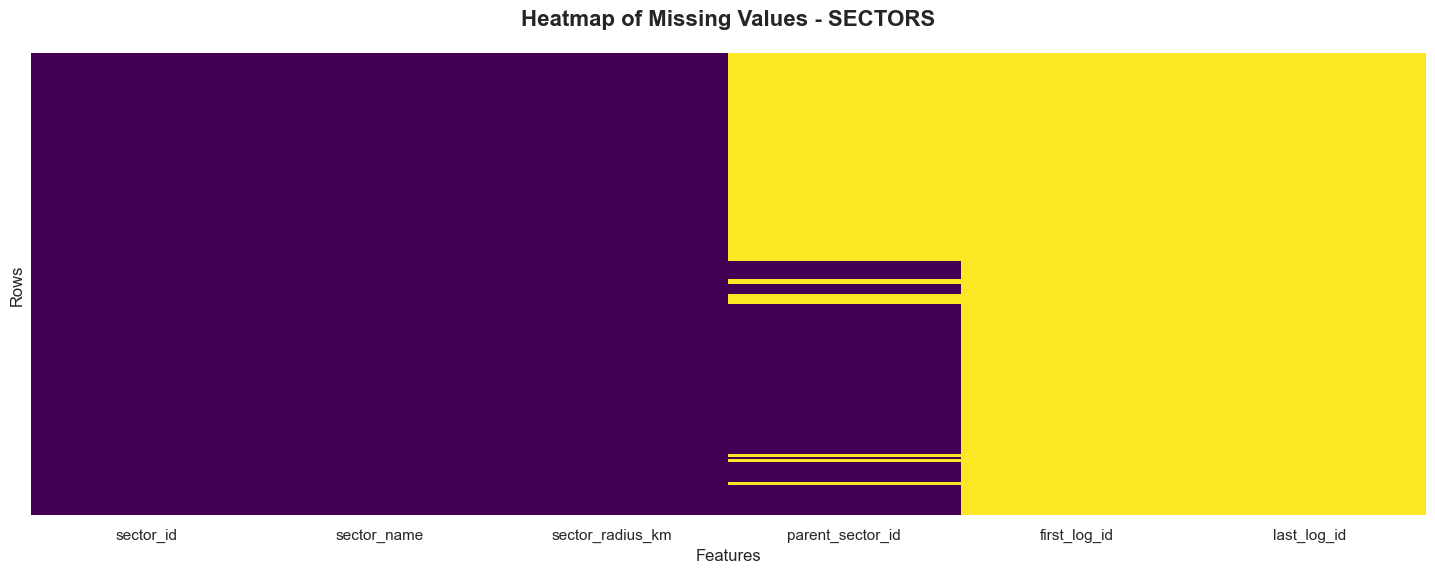

In [52]:
missing_values_heatmap(sectors_df,"SECTORS")

In [53]:
sectors_df = sectors_df.drop(['first_log_id', 'last_log_id'], axis=1)

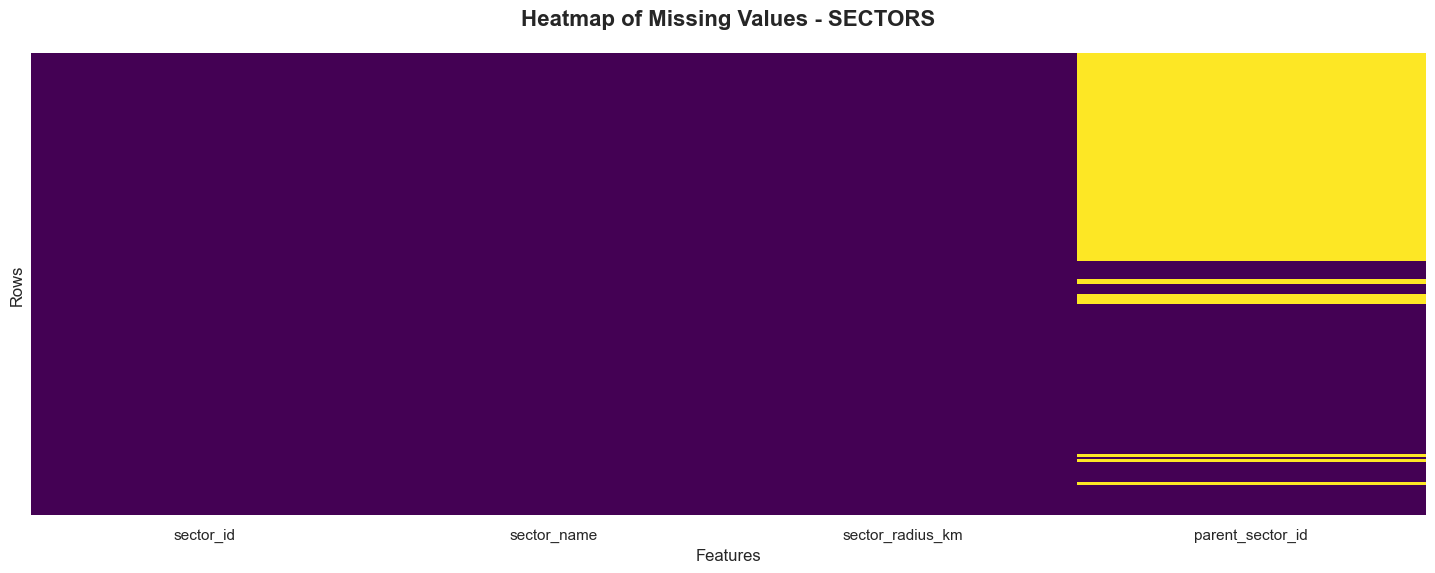

In [54]:
missing_values_heatmap(sectors_df,"SECTORS")

In [55]:
sectors_df.head()

,sector_id,sector_name,sector_radius_km,parent_sector_id
0,1,Advertising Agencies,25,NaN
1,50,Aerospace and Defense,25,NaN
2,2,Agriculture,25,NaN
3,97,Alternative Asset Management,25,NaN
4,3,Alternative Energy,25,NaN


In [56]:
sectors_df['parent_sector_id'] = sectors_df['parent_sector_id'].fillna(0)

In [57]:
get_missing_value_summary(sectors_df)

,Column,Dtype,TotalValues,MissingValues,NonMissingValues,MissingPercent
0,sector_id,int64,182,0,182,0.0
1,sector_name,object,182,0,182,0.0
2,sector_radius_km,int64,182,0,182,0.0
3,parent_sector_id,float64,182,0,182,0.0


### **3.3.3. Unique Values Information**

In [72]:
cat_cols_sectors, int_cols_sectors, float_cols_sectors = get_column_types(sectors_df)

Categorical variables:
['sector_name']

Integer variables:
['sector_id', 'sector_radius_km']

Real (float) variables:
['parent_sector_id']


In [73]:
unique_values(sectors_df)

,Column,UniqueValues,TotalValues,UniquePercent
0,sector_id,182,182,100.00
1,sector_name,182,182,100.00
2,parent_sector_id,23,182,12.64
3,sector_radius_km,6,182,3.30


In [74]:
sectors_df['sector_radius_km'].value_counts()

sector_radius_km
25     124
3       34
250     10
10       7
5        5
100      2
Name: count, dtype: int64

In [75]:
companies_df.head()

,cib_id,company_name,hq_country_id,operation,operation_date
0,aap-joints.com,aap Joints,DE,NEW_BATCH_MANUAL,2025-12-04
1,abacoadjusters.com,Abaco International Loss Adjusters,ES,NEW_BATCH,2024-12-15
2,abgagservices.com,ABG AG,US,NEW_BATCH_MANUAL,2025-12-04
3,abu-gmbh.ch,ABUplus,CH,NEW_BATCH_JENKINS,2025-11-27
4,abundantlivinginsurance.com,Abundant Living,US,NEW_BATCH,2024-12-22


In [76]:
company_sectors_df.head()

,cib_id,sector_id
0,aap-joints.com,25
1,abacoadjusters.com,22
2,abgagservices.com,214
3,abu-gmbh.ch,167
4,abundantlivinginsurance.com,22


In [77]:
sectors_df.head()

,sector_id,sector_name,sector_radius_km,parent_sector_id
0,1,Advertising Agencies,25,0.0
1,50,Aerospace and Defense,25,0.0
2,2,Agriculture,25,0.0
3,97,Alternative Asset Management,25,0.0
4,3,Alternative Energy,25,0.0


# 4. Merge Datasets

In [78]:
# Merge companies with company_sectors
df_merged = companies_df.merge(company_sectors_df, on='cib_id', how='left')

In [79]:
df_merged.head()

,cib_id,company_name,hq_country_id,operation,operation_date,sector_id
0,aap-joints.com,aap Joints,DE,NEW_BATCH_MANUAL,2025-12-04,25
1,abacoadjusters.com,Abaco International Loss Adjusters,ES,NEW_BATCH,2024-12-15,22
2,abgagservices.com,ABG AG,US,NEW_BATCH_MANUAL,2025-12-04,214
3,abu-gmbh.ch,ABUplus,CH,NEW_BATCH_JENKINS,2025-11-27,167
4,abundantlivinginsurance.com,Abundant Living,US,NEW_BATCH,2024-12-22,22


In [81]:
df_merged.shape

(1324, 6)

In [82]:
# Merge with sectors info
df_merged = df_merged.merge(sectors_df, on='sector_id', how='left')

In [83]:
df_merged.shape

(1324, 9)

In [84]:
# Aggregate multiple sectors per company
df_app = df_merged.groupby(
    ['cib_id', 'company_name', 'hq_country_id', 'operation', 'operation_date']
).agg({
    'sector_id': list,
    'sector_name': list,
    'sector_radius_km': list,
    'parent_sector_id': list
}).reset_index()

In [86]:
df_app.shape

(1000, 9)

In [87]:
df_app.head()

,cib_id,company_name,hq_country_id,operation,operation_date,sector_id,sector_name,sector_radius_km,parent_sector_id
0,a-reinhard.ch,Arvag,CH,NEW_BATCH_JENKINS,2025-11-27,[167],[Companies from Jenkins],[25],[0.0]
1,aap-joints.com,aap Joints,DE,NEW_BATCH_MANUAL,2025-12-04,[25],[Medical Equipment and Supplies],[25],[0.0]
2,abacoadjusters.com,Abaco International Loss Adjusters,ES,NEW_BATCH,2024-12-15,[22],[Insurance Brokers],[25],[0.0]
3,abgagservices.com,ABG AG,US,NEW_BATCH_MANUAL,2025-12-04,[214],[Medtech Services 3],[25],[0.0]
4,abu-gmbh.ch,ABUplus,CH,NEW_BATCH_JENKINS,2025-11-27,[167],[Companies from Jenkins],[25],[0.0]


In [91]:
df_app.columns

Index(['cib_id', 'company_name', 'hq_country_id', 'operation',
       'operation_date', 'sector_id', 'sector_name', 'sector_radius_km',
       'parent_sector_id'],
      dtype='object')

In [92]:
df_app.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   cib_id            1000 non-null   object
 1   company_name      1000 non-null   object
 2   hq_country_id     1000 non-null   object
 3   operation         1000 non-null   object
 4   operation_date    1000 non-null   object
 5   sector_id         1000 non-null   object
 6   sector_name       1000 non-null   object
 7   sector_radius_km  1000 non-null   object
 8   parent_sector_id  1000 non-null   object
dtypes: object(9)
memory usage: 70.4+ KB


In [93]:
df_app.describe()

,cib_id,company_name,hq_country_id,operation,operation_date,sector_id,sector_name,sector_radius_km,parent_sector_id
count,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,1000,1000,50,5,108,65,65,11,19
top,a-reinhard.ch,Arvag,CH,NEW_BATCH_JENKINS,2025-11-27,[167],[Companies from Jenkins],[25],[0.0]
freq,1,1,390,478,319,478,478,649,688


In [94]:
df_app.isna().sum()

cib_id              0
company_name        0
hq_country_id       0
operation           0
operation_date      0
sector_id           0
sector_name         0
sector_radius_km    0
parent_sector_id    0
dtype: int64

In [98]:
data_folder = project_root / 'data'

In [ ]:
csv_file_path_company = data_folder / 'company_info.csv'

In [ ]:
df_app.to_csv(csv_file_path_company, index=False)

In [103]:
csv_file_path_sectors = data_folder / 'sectors_info.csv'

In [104]:
sectors_df.to_csv(csv_file_path_sectors, index=False)

In [105]:
sectors_df.columns

Index(['sector_id', 'sector_name', 'sector_radius_km', 'parent_sector_id'], dtype='object')